<a href="https://colab.research.google.com/github/vanshikaav/Startup-Risk-Assessment/blob/main/StartupRiskAssessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h4>Problem Statement : </h4>
The objective of this project is to develop a Startup Failure Risk Assessment System that predicts the likelihood of startup failure using founder behaviour, operational characteristics, financial health, and organizational characteristics.The system provides early risk warnings and actionable insights to help founders, investors, and incubators improve startup survival rates.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df= pd.read_csv('startup_founder_burnout_2026.csv')

<h3>1. Business Understanding</h3>

**1. What business problem are we solving?**

We are building a system to predict whether a startup is at risk of failure using founder, operational, and financial factors.
The goal is to identify warning signs early before the startup reaches a critical stage.

**2. Why is this problem important?**

A large percentage of startups fail due to issues such as burnout, poor product-market fit, and financial instability.
Early risk prediction enables proactive decisions that can improve startup survival and growth.

**3. Who are the stakeholders?**

The primary stakeholders are startup founders, investors, venture capital firms, incubators, and startup accelerators.
These stakeholders can use the system to assess risk and make more informed strategic decisions.

**4. What decision will our risk assessment help users make?**

The system helps users determine whether a startup requires immediate intervention or corrective action.
It supports decisions related to funding, mentoring, operational improvements, and risk management.


In [11]:
df.head()

,Founder_Type,Economic_Climate,Founder_Age,Founder_Experience_Years,Industry,Funding_Stage,Work_Mode,Team_Size,Startup_Age_Months,Weekly_Work_Hours,...,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Seeks_Mental_Health_Support,Shutdown_Probability,Shutdown_Risk,Startup_Failure_Flag
0,Serial Entrepreneur,Recession,31.0,12.0,E-commerce,Seed,Remote,14.0,99.0,48.5,...,0.0,-5.1,5.6,7.8,30.0,9.7,No,0.082,Low,0.0
1,Calm Operator,Recession,30.0,0.0,FinTech,Bootstrapped,Remote,6.0,47.0,48.6,...,0.0,2.7,8.4,2.3,14.4,10.0,No,0.490,Medium,0.0
2,Burned-Out Operator,Stable Economy,28.0,3.0,ClimateTech,Bootstrapped,Hybrid,5.0,59.0,68.8,...,0.0,16.3,4.4,1.0,41.5,4.0,No,0.905,High,1.0
3,Chaotic Innovator,Stable Economy,32.0,2.0,EdTech,Series A,Office,74.0,143.0,81.5,...,0.0,-1.4,31.5,4.0,39.4,5.1,No,0.233,Low,0.0
4,Growth Obsessed Founder,Stable Economy,35.0,1.0,SaaS,Pre-Seed,Hybrid,9.0,11.0,78.6,...,0.0,21.6,7.0,5.2,36.5,4.2,No,0.716,High,1.0


<h3>2. Data Understanding</h3>
<b>2.1 What are we trying to predict?</b><br>
Our target is <i>Startup_Failure_Flag</i><br>
0 = Startup Survived<br>
1 = Startup Failed<br>
This makes our project a <b>Binary Classification Problem</b> <br><br>

<b>2.2 How many observations do we have?</b><br>
50,000 startup rows<br>
29 features<br><br>

<b>2.3 What does one row represent?</b><br>
One startup-founder profile

In [12]:
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset Shape: 34692 rows × 29 columns


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34692 entries, 0 to 34691
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Founder_Type                    34692 non-null  object 
 1   Economic_Climate                34691 non-null  object 
 2   Founder_Age                     34691 non-null  float64
 3   Founder_Experience_Years        34691 non-null  float64
 4   Industry                        34691 non-null  object 
 5   Funding_Stage                   34691 non-null  object 
 6   Work_Mode                       34691 non-null  object 
 7   Team_Size                       34691 non-null  float64
 8   Startup_Age_Months              34691 non-null  float64
 9   Weekly_Work_Hours               34691 non-null  float64
 10  Sleep_Hours                     34691 non-null  float64
 11  Exercise_Days_Per_Week          34691 non-null  float64
 12  Vacation_Days_Taken             

In [14]:
df.drop(['Shutdown_Probability','Shutdown_Risk'],axis=1,inplace=True)   #to prevent data leakage

In [15]:
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset Shape: 34692 rows × 27 columns


In [16]:
cat_cols=['Founder_Type','Economic_Climate','Industry','Funding_Stage','Work_Mode','Burnout_Level','Founder_Burnout_Flag','Seeks_Mental_Health_Support',   'Startup_Failure_Flag']

num_cols=['Founder_Age','Founder_Experience_Years','Team_Size', 'Startup_Age_Months', 'Weekly_Work_Hours', 'Sleep_Hours',
       'Exercise_Days_Per_Week', 'Vacation_Days_Taken','Investor_Pressure_Score', 'Cofounder_Conflict_Score', 'Stress_Score',
       'Decision_Fatigue_Score', 'Burnout_Score', 'Monthly_Revenue_Growth_Percent',
       'Runway_Months_Remaining', 'Product_Market_Fit_Score','Employee_Turnover_Percent', 'Work_Life_Balance_Score']

In [17]:
df.isnull().sum()   # no missing vals found

,0
Founder_Type,0
Economic_Climate,1
Founder_Age,1
Founder_Experience_Years,1
Industry,1
Funding_Stage,1
Work_Mode,1
Team_Size,1
Startup_Age_Months,1
Weekly_Work_Hours,1


In [18]:
df.duplicated().sum()   # no duplicate found

np.int64(0)

In [19]:
df['Startup_Failure_Flag'].value_counts()

,count
Startup_Failure_Flag,
0.0,26495
1.0,8196


In [20]:
#verifying class imbalance

print("Non-Failure =", df['Startup_Failure_Flag'].value_counts()[0]*100/50000)
print("Failure =",df['Startup_Failure_Flag'].value_counts()[1]*100/50000)

Non-Failure = 52.99
Failure = 16.392


In [21]:
print("Categorical Columns Distribution:\n")
for i in cat_cols:
    print(df[i].value_counts(),"\n\n")

Categorical Columns Distribution:

Founder_Type
Technical Builder          6246
Solo Hustler               6174
Serial Entrepreneur        4942
Growth Obsessed Founder    4902
Visionary CEO              3508
Burned-Out Operator        3422
Chaotic Innovator          2776
Calm Operator              2721
Tec                           1
Name: count, dtype: int64 


Economic_Climate
Stable Economy    15529
Funding Winter     7723
Bull Market        6266
Recession          5173
Name: count, dtype: int64 


Industry
SaaS             6264
AI               6251
E-commerce       4168
FinTech          4052
HealthTech       2828
Cybersecurity    2786
EdTech           2755
Gaming           2096
ClimateTech      1777
Biotech          1714
Name: count, dtype: int64 


Funding_Stage
Seed            9267
Series A        7021
Pre-Seed        6981
Bootstrapped    6100
Series B        3514
Series C        1808
Name: count, dtype: int64 


Work_Mode
Remote    15494
Hybrid    13920
Office     5277
Name: co

In [22]:
print("Numerical Columns Distribution:\n")
df.describe()

Numerical Columns Distribution:



,Founder_Age,Founder_Experience_Years,Team_Size,Startup_Age_Months,Weekly_Work_Hours,Sleep_Hours,Exercise_Days_Per_Week,Vacation_Days_Taken,Investor_Pressure_Score,Cofounder_Conflict_Score,Stress_Score,Decision_Fatigue_Score,Burnout_Score,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Startup_Failure_Flag
count,34691.000000,34691.000000,34691.000000,34691.000000,34691.000000,34691.000000,34691.000000,34691.000000,34691.000000,34691.00000,34691.000000,34691.000000,34691.000000,34691.000000,34691.000000,34691.000000,34691.000000,34691.000000,34691.000000,34691.000000
mean,34.122914,2.635986,55.845637,72.535701,63.714482,5.690796,3.754302,9.242426,6.153559,4.01281,5.115059,4.506339,3.445920,0.108443,5.556727,12.406097,5.330910,35.928575,6.742322,0.236257
std,6.514821,2.107922,114.548739,40.977762,13.146134,1.007217,1.296725,6.522337,2.231937,2.33548,2.498270,2.586939,2.231998,0.310944,14.518549,6.315604,2.397946,16.431451,2.745680,0.424788
min,21.000000,0.000000,1.000000,2.000000,28.000000,2.800000,0.000000,0.000000,1.000000,0.00000,1.000000,1.000000,1.000000,0.000000,-45.000000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,30.000000,1.000000,6.000000,37.000000,54.800000,5.000000,2.900000,4.000000,4.600000,2.30000,3.200000,2.300000,1.200000,0.000000,-3.500000,7.900000,3.600000,23.900000,4.700000,0.000000
50%,34.000000,2.000000,16.000000,72.000000,63.600000,5.700000,3.700000,8.900000,6.200000,4.00000,5.100000,4.200000,3.100000,0.000000,4.100000,12.300000,5.300000,35.100000,7.100000,0.000000
75%,39.000000,4.000000,55.000000,108.000000,72.600000,6.400000,4.600000,13.700000,7.800000,5.60000,6.900000,6.400000,5.000000,0.000000,14.500000,16.700000,7.100000,47.100000,9.300000,0.000000
max,61.000000,12.000000,799.000000,143.000000,110.000000,9.000000,7.000000,35.000000,10.000000,10.00000,10.000000,10.000000,10.000000,1.000000,70.300000,36.000000,10.000000,97.300000,10.000000,1.000000


<h3>EDA</h3>

In [23]:
corr_target= df.corr(numeric_only=True)['Startup_Failure_Flag'].sort_values(ascending=False)
print(corr_target)

print("\n\nInterpretation:\n")
print("Higher burnout → higher failure risk\nMore employees leaving → higher failure risk\nMore decision fatigue → higher failure risk\nHigher stress → higher failure risk\nMore cofounder conflict → higher failure risk")

Startup_Failure_Flag              1.000000
Burnout_Score                     0.505001
Employee_Turnover_Percent         0.448559
Decision_Fatigue_Score            0.438312
Stress_Score                      0.424957
Cofounder_Conflict_Score          0.414597
Founder_Burnout_Flag              0.368657
Weekly_Work_Hours                 0.321809
Investor_Pressure_Score           0.158355
Startup_Age_Months               -0.000746
Team_Size                        -0.050348
Founder_Age                      -0.065118
Monthly_Revenue_Growth_Percent   -0.100207
Founder_Experience_Years         -0.165396
Vacation_Days_Taken              -0.175466
Exercise_Days_Per_Week           -0.222199
Sleep_Hours                      -0.257991
Runway_Months_Remaining          -0.380525
Product_Market_Fit_Score         -0.387106
Work_Life_Balance_Score          -0.469645
Name: Startup_Failure_Flag, dtype: float64


Interpretation:

Higher burnout → higher failure risk
More employees leaving → higher failure r

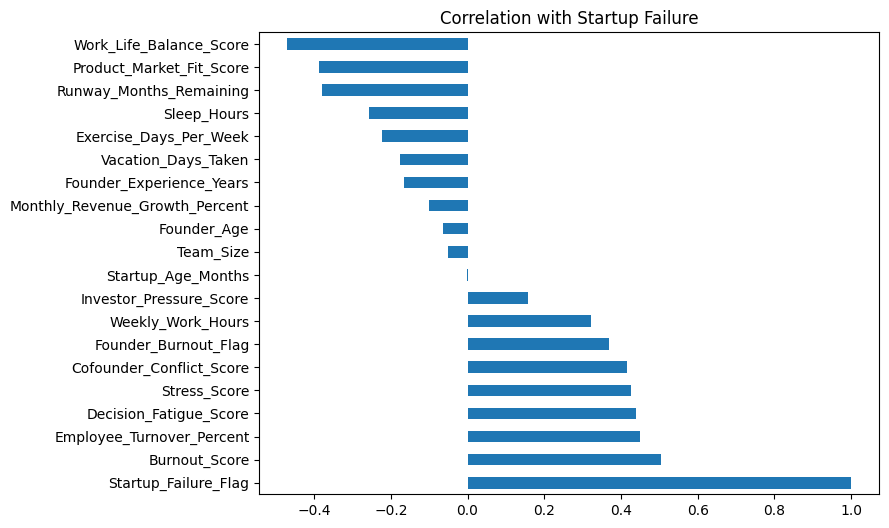

Top positive correlations increase failure risk.
Top negative correlations reduce failure risk.


In [24]:
corr_target.plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Correlation with Startup Failure")
plt.show()

print("Top positive correlations increase failure risk.")
print("Top negative correlations reduce failure risk.")

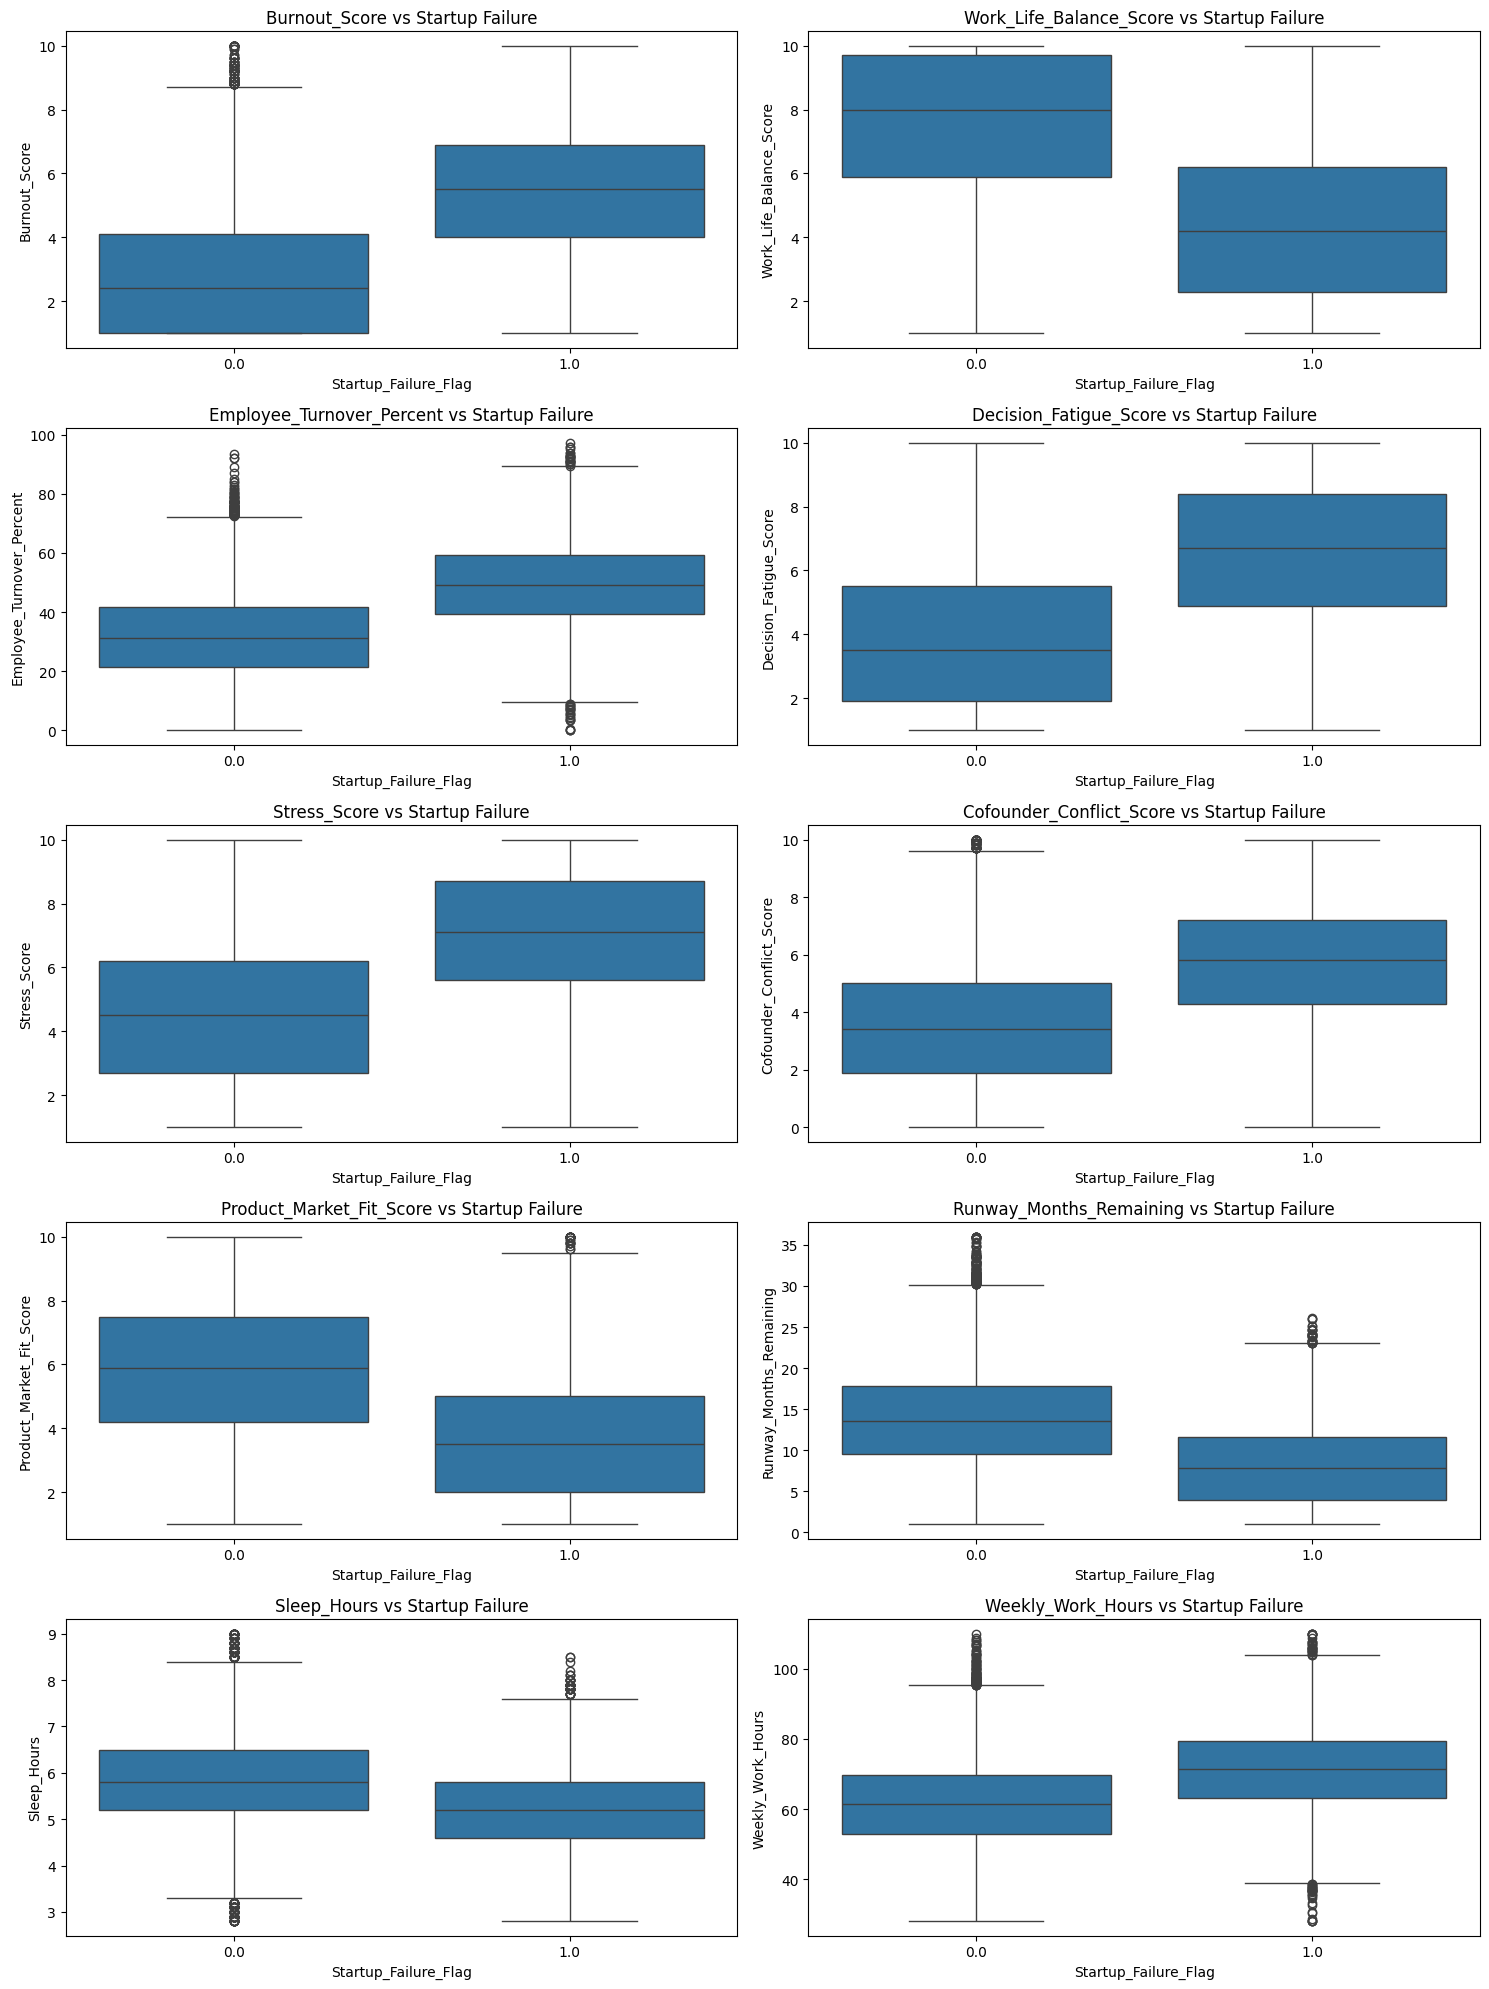

In [25]:
eda_features = [
    'Burnout_Score',
    'Work_Life_Balance_Score',
    'Employee_Turnover_Percent',
    'Decision_Fatigue_Score',
    'Stress_Score',
    'Cofounder_Conflict_Score',
    'Product_Market_Fit_Score',
    'Runway_Months_Remaining',
    'Sleep_Hours',
    'Weekly_Work_Hours'
]

fig, axes = plt.subplots(5,2, figsize=(15,20))

for ax, col in zip(axes.flatten(), eda_features):

    sns.boxplot(
        data=df,
        x='Startup_Failure_Flag',
        y=col,
        ax=ax
    )

    ax.set_title(f'{col} vs Startup Failure')

plt.tight_layout()
plt.show()

In [26]:
for col in eda_features:

    success = df[df['Startup_Failure_Flag']==0][col].mean()
    failure = df[df['Startup_Failure_Flag']==1][col].mean()

    print(f"\n{'='*50}")
    print(f"Feature: {col}")

    print(f"Successful Startups Mean : {success:.2f}")
    print(f"Failed Startups Mean     : {failure:.2f}")

    if failure > success:
        print(f"📈 Higher {col} is associated with startup failure.")
    else:
        print(f"📉 Lower {col} is associated with startup failure.")


Feature: Burnout_Score
Successful Startups Mean : 2.82
Failed Startups Mean     : 5.47
📈 Higher Burnout_Score is associated with startup failure.

Feature: Work_Life_Balance_Score
Successful Startups Mean : 7.46
Failed Startups Mean     : 4.42
📉 Lower Work_Life_Balance_Score is associated with startup failure.

Feature: Employee_Turnover_Percent
Successful Startups Mean : 31.83
Failed Startups Mean     : 49.18
📈 Higher Employee_Turnover_Percent is associated with startup failure.

Feature: Decision_Fatigue_Score
Successful Startups Mean : 3.88
Failed Startups Mean     : 6.54
📈 Higher Decision_Fatigue_Score is associated with startup failure.

Feature: Stress_Score
Successful Startups Mean : 4.52
Failed Startups Mean     : 7.02
📈 Higher Stress_Score is associated with startup failure.

Feature: Cofounder_Conflict_Score
Successful Startups Mean : 3.47
Failed Startups Mean     : 5.75
📈 Higher Cofounder_Conflict_Score is associated with startup failure.

Feature: Product_Market_Fit_Score


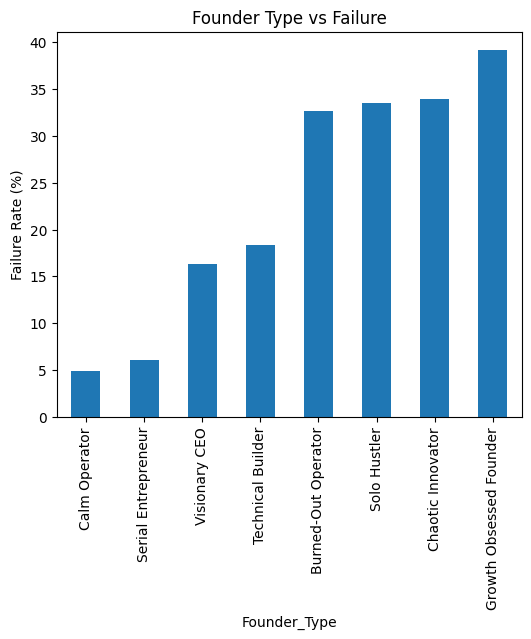

In [27]:
failure_rate = pd.crosstab(
    df['Founder_Type'],
    df['Startup_Failure_Flag'],
    normalize='index'
)*100

failure_rate[1].sort_values().plot(
    kind='bar',
    figsize=(6,5)
)
plt.title("Founder Type vs Failure")
plt.ylabel("Failure Rate (%)")
plt.show()

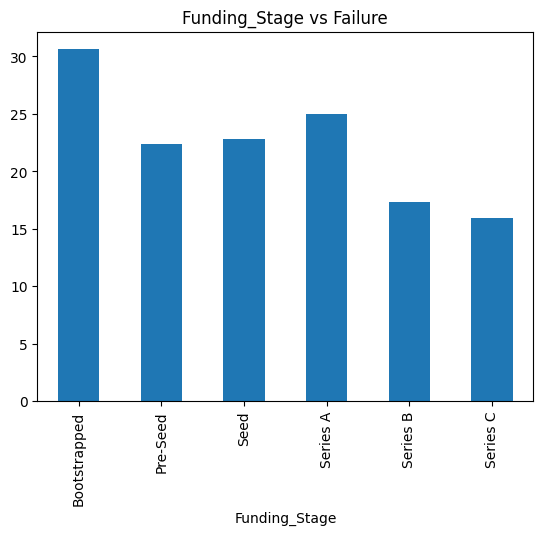

In [28]:
failure_rate = pd.crosstab(
    df['Funding_Stage'],
    df['Startup_Failure_Flag'],
    normalize='index'
)*100

failure_rate[1].plot(kind='bar')
plt.title("Funding_Stage vs Failure")
plt.show()

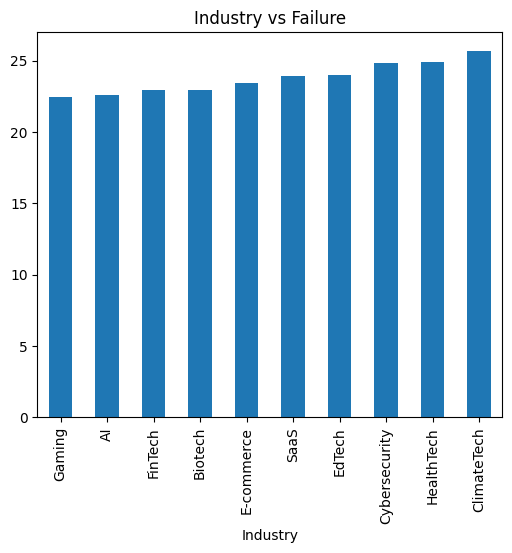

In [29]:
failure_rate = pd.crosstab(
    df['Industry'],
    df['Startup_Failure_Flag'],
    normalize='index'
)*100

failure_rate[1].sort_values().plot(
    kind='bar',
    figsize=(6,5)
)
plt.title("Industry vs Failure")
plt.show()

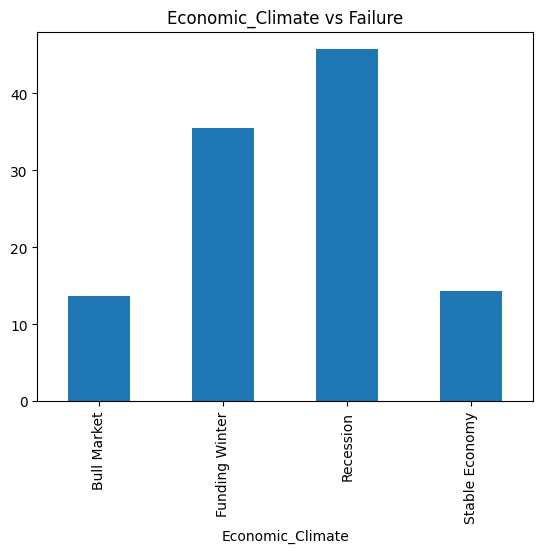

In [30]:
failure_rate = pd.crosstab(
    df['Economic_Climate'],
    df['Startup_Failure_Flag'],
    normalize='index'
)*100

failure_rate[1].plot(kind='bar')
plt.title("Economic_Climate vs Failure")
plt.show()

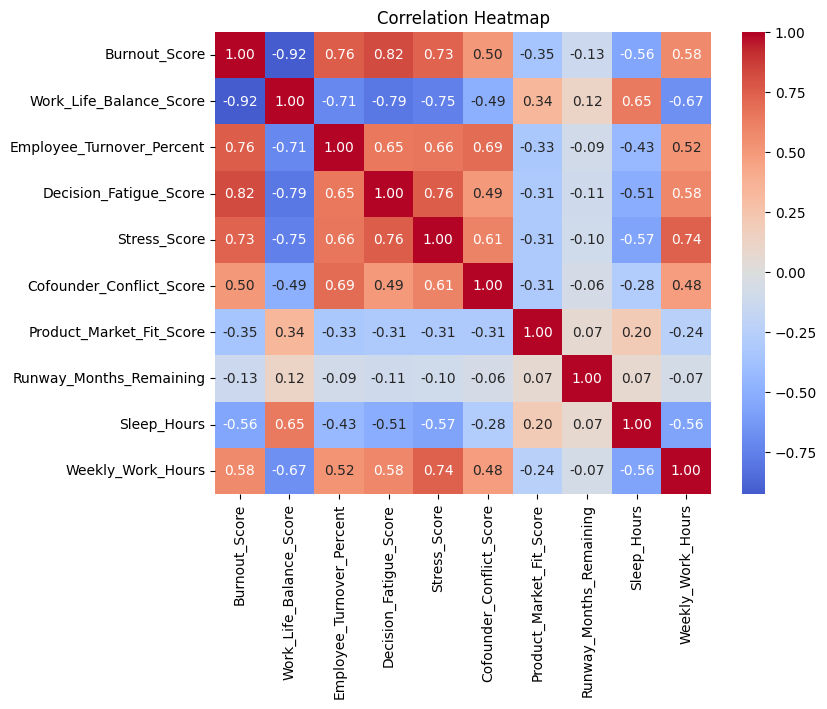

In [31]:
corr_matrix = df[eda_features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

<h3>Data Preprocessing</h3>
1.Convert all text columns to numbers using LabelEncoder<br>
2.Define our features (X) and target (y)<br>
3.Split data into train and test sets<br><br>



<i>Train set = what the model learns from</i><br>
<i>Test set = how we check if it learned well (unseen data)</i><br>

In [32]:
df.dtypes

,0
Founder_Type,object
Economic_Climate,object
Founder_Age,float64
Founder_Experience_Years,float64
Industry,object
Funding_Stage,object
Work_Mode,object
Team_Size,float64
Startup_Age_Months,float64
Weekly_Work_Hours,float64


In [33]:
df_copy = df.copy()

In [48]:
# feature and target

df_copy.dropna(subset=['Startup_Failure_Flag'], inplace=True)
X = df_copy.drop('Startup_Failure_Flag', axis=1)
y = df_copy['Startup_Failure_Flag']

print("Input features : ",X.shape[0],"rows",X.shape[1],"cols")
print("Output feature : ",y.shape[0],"rows","1","col")

Input features :  34691 rows 26 cols
Output feature :  34691 rows 1 col


In [49]:
#encode categorical features

cat_cols = X.select_dtypes(include='object').columns
print(cat_cols)

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le


Index(['Founder_Type', 'Economic_Climate', 'Industry', 'Funding_Stage',
       'Work_Mode', 'Burnout_Level', 'Seeks_Mental_Health_Support'],
      dtype='object')


In [50]:
X.head()

,Founder_Type,Economic_Climate,Founder_Age,Founder_Experience_Years,Industry,Funding_Stage,Work_Mode,Team_Size,Startup_Age_Months,Weekly_Work_Hours,...,Decision_Fatigue_Score,Burnout_Score,Burnout_Level,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Seeks_Mental_Health_Support
0,4,2,31.0,12.0,4,2,2,14.0,99.0,48.5,...,2.6,1.0,0,0.0,-5.1,5.6,7.8,30.0,9.7,0
1,1,2,30.0,0.0,6,0,2,6.0,47.0,48.6,...,1.7,1.0,0,0.0,2.7,8.4,2.3,14.4,10.0,0
2,0,3,28.0,3.0,2,0,0,5.0,59.0,68.8,...,9.0,5.8,1,0.0,16.3,4.4,1.0,41.5,4.0,0
3,2,3,32.0,2.0,5,3,1,74.0,143.0,81.5,...,5.4,5.6,1,0.0,-1.4,31.5,4.0,39.4,5.1,0
4,3,3,35.0,1.0,9,1,0,9.0,11.0,78.6,...,3.4,4.6,1,0.0,21.6,7.0,5.2,36.5,4.2,0


In [51]:
X.duplicated().sum()

np.int64(0)

In [52]:
X.dtypes

,0
Founder_Type,int64
Economic_Climate,int64
Founder_Age,float64
Founder_Experience_Years,float64
Industry,int64
Funding_Stage,int64
Work_Mode,int64
Team_Size,float64
Startup_Age_Months,float64
Weekly_Work_Hours,float64


<h3>Model Training</h3>

We work with three models here for the binary classification:
1. Logistic Regression
2. Random Forest
3. Xgboost

In [53]:
# train-test-split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(X,y,
                                                  test_size=0.2,
                                                  random_state=42,
                                                  stratify=y
                                                  )

In [54]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (27752, 26)
X_test : (6939, 26)
y_train: (27752,)
y_test : (6939,)


<h2>Cross Validation + Hyperparameter Tuning</h2>

<h4>Logistic Regression</h4>

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

param_lr = {
    'model__C':[0.01,0.1,1,10]
}

grid_lr = GridSearchCV(
    pipe_lr,
    param_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_lr.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', LogisticRegression())]),
             n_jobs=-1, param_grid={'model__C': [0.01, 0.1, 1, 10]},
             scoring='roc_auc')

<h4>Random Forest Classifier</h4>

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

param_rf = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,20,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

rf_search = RandomizedSearchCV(
    rf,
    param_rf,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 20, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='roc_auc')

<h4>XGBoost</h4>

In [59]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

param_xgb = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.8,1.0],
    'colsample_bytree':[0.8,1.0]
}

xgb_search = RandomizedSearchCV(
    xgb,
    param_xgb,
    cv=5,
    n_iter=20,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='roc_auc')

Insights:

• Hyperparameter tuning improved model performance.<br>
• Cross-validation reduces overfitting risk.<br>
• XGBoost explored multiple tree depths and learning rates.<br>
• Random Forest explored different tree structures.<br>

<h3>Comparing Validation Performance</h3>

In [60]:
comparison_cv = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "CV ROC-AUC":[
        grid_lr.best_score_,
        rf_search.best_score_,
        xgb_search.best_score_
    ]
})

comparison_cv.sort_values(
    by="CV ROC-AUC",
    ascending=False
)

,Model,CV ROC-AUC
2,XGBoost,0.948732
1,Random Forest,0.938337
0,Logistic Regression,0.937807


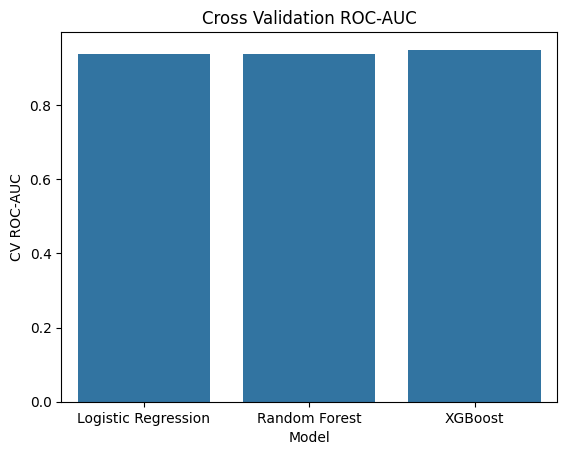

In [61]:
sns.barplot(
    data=comparison_cv,
    x='Model',
    y='CV ROC-AUC'
)
plt.title("Cross Validation ROC-AUC")
plt.show()

In [62]:
best_model = xgb_search.best_estimator_

In [63]:
#final test evaluation

from sklearn.metrics import *

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]


print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision :",precision_score(y_test,y_pred))
print("Recall :",recall_score(y_test,y_pred))
print("F1 :",f1_score(y_test,y_pred))
print("ROC AUC :",roc_auc_score(y_test,y_prob))

Accuracy : 0.8940769563337657
Precision : 0.7935064935064935
Recall : 0.7455765710799268
F1 : 0.7687952186222082
ROC AUC : 0.9514427803423624


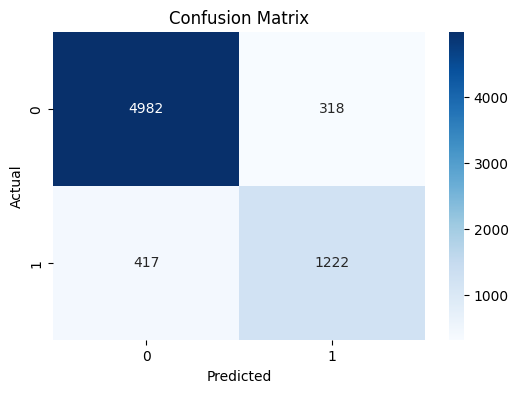

In [64]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Insights:

• The model correctly identifies most failed startups.<br>
• False negatives are limited, reducing the chance of missing high-risk startups.<br>
• Strong ROC-AUC indicates excellent ranking capability.<br>

In [65]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93      5300
         1.0       0.79      0.75      0.77      1639

    accuracy                           0.89      6939
   macro avg       0.86      0.84      0.85      6939
weighted avg       0.89      0.89      0.89      6939



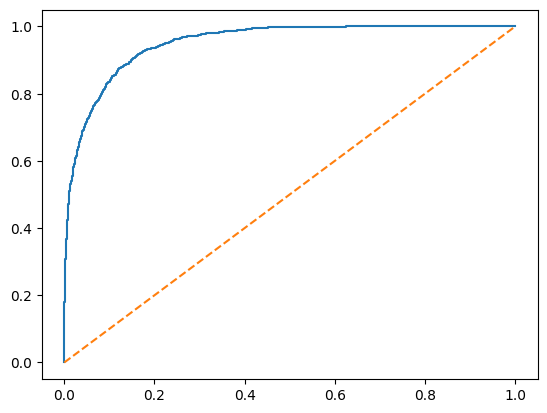

In [66]:
from sklearn.metrics import roc_curve

fpr,tpr,_ = roc_curve(y_test,y_prob)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')

Insights:

• ROC curve is significantly above the random baseline.<br>
• Model demonstrates strong discrimination ability.<br>
• High ROC-AUC confirms reliable startup risk ranking.<br>

XGBoost achieved the highest overall performance with the best Accuracy, Precision, Recall, and F1-Score.

Random Forest produced competitive results but slightly underperformed compared to XGBoost.

Logistic Regression served as a baseline model and showed lower performance because startup failure depends on complex non-linear relationships among founder behavior, financial metrics, and operational factors.

<h3>FEATURE IMPORTANCE</h3>
Which variables influence startup failure most?

In [69]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

top20 = importance.sort_values(
    ascending=False
).head(20)

<Axes: >

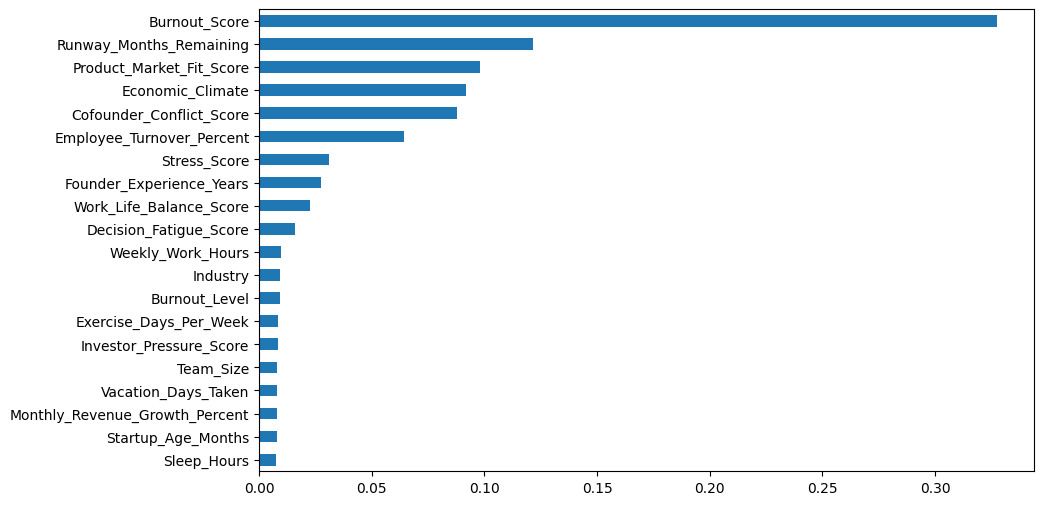

In [70]:
top20.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

Insights:

• Burnout Score is one of the strongest predictors.<br>
• Product-Market Fit strongly reduces failure risk.<br>
• Low runway months increase failure probability.<br>
• Work-Life Balance shows significant influence.<br>

In [71]:
import joblib

joblib.dump(best_model, "startup_failure_model.pkl")

['startup_failure_model.pkl']